# Обнаружение аномалий во временных рядах с использованием LSTM-автоэнкодеров на PyTorch

Лабораторная работа основана на материалах [этого блокнота](https://colab.research.google.com/github/curiousily/Getting-Things-Done-with-Pytorch/blob/master/06.time-series-anomaly-detection-ecg.ipynb).

In [ ]:
import copy
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## Подготовка данных

Подготовим набор данных для обнаружения аномалий во временных рядах

Будем использовать нормальные сердечные циклы в качестве обучающих данных для нашей модели и оценивать ошибку реконструкции.

In [ ]:
# Настройки среды
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Загрузка данных
train_df_raw = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv", header=None)
test_df_raw = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv", header=None)

train_df_raw.rename(columns={187: 'target'}, inplace=True)
test_df_raw.rename(columns={187: 'target'}, inplace=True)

# Объединим, чтобы сделать чистое разделение на Train/Val/Test по логике автоэнкодера
full_df = pd.concat([train_df_raw, test_df_raw], axis=0).reset_index(drop=True)

# Выделяем нормальные и аномальные данные
normal_df = full_df[full_df.target == 0.0].drop(labels='target', axis=1)
anomaly_df = full_df[full_df.target != 0.0].drop(labels='target', axis=1)

print(f"Всего нормальных семплов: {normal_df.shape[0]}")
print(f"Всего аномальных семплов: {anomaly_df.shape[0]}")

# Разделяем НОРМАЛЬНЫЕ данные на train, val и test
train_df, val_df = train_test_split(normal_df, test_size=0.15, random_state=RANDOM_SEED)
val_df, test_normal_df = train_test_split(val_df, test_size=0.33, random_state=RANDOM_SEED)

Всего нормальных семплов: 90589
Всего аномальных семплов: 18857


In [ ]:
def create_dataset(df):
    sequences = df.astype(np.float32).to_numpy().tolist()
    dataset = [torch.tensor(s).unsqueeze(1).float() for s in sequences]
    n_seq, seq_len, n_features = torch.stack(dataset).shape
    return dataset, seq_len, n_features

train_dataset, seq_len, n_features = create_dataset(train_df)
val_dataset, _, _ = create_dataset(val_df)
test_normal_dataset, _, _ = create_dataset(test_normal_df)
test_anomaly_dataset, _, _ = create_dataset(anomaly_df)

BATCH_SIZE = 256 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Для инференса
test_normal_loader = DataLoader(test_normal_dataset, batch_size=1, shuffle=False)
test_anomaly_loader = DataLoader(test_anomaly_dataset, batch_size=1, shuffle=False)

К концу этого урока вы научитесь:

- Подготавливать набор данных для обнаружения аномалий во временных рядах
- Создавать LSTM-автоэнкодер с помощью PyTorch
- Обучать и оценивать вашу модель
- Выбирать порог для обнаружения аномалий
- Классифицировать новые примеры как нормальные или аномальные

## Исследовательский анализ данных

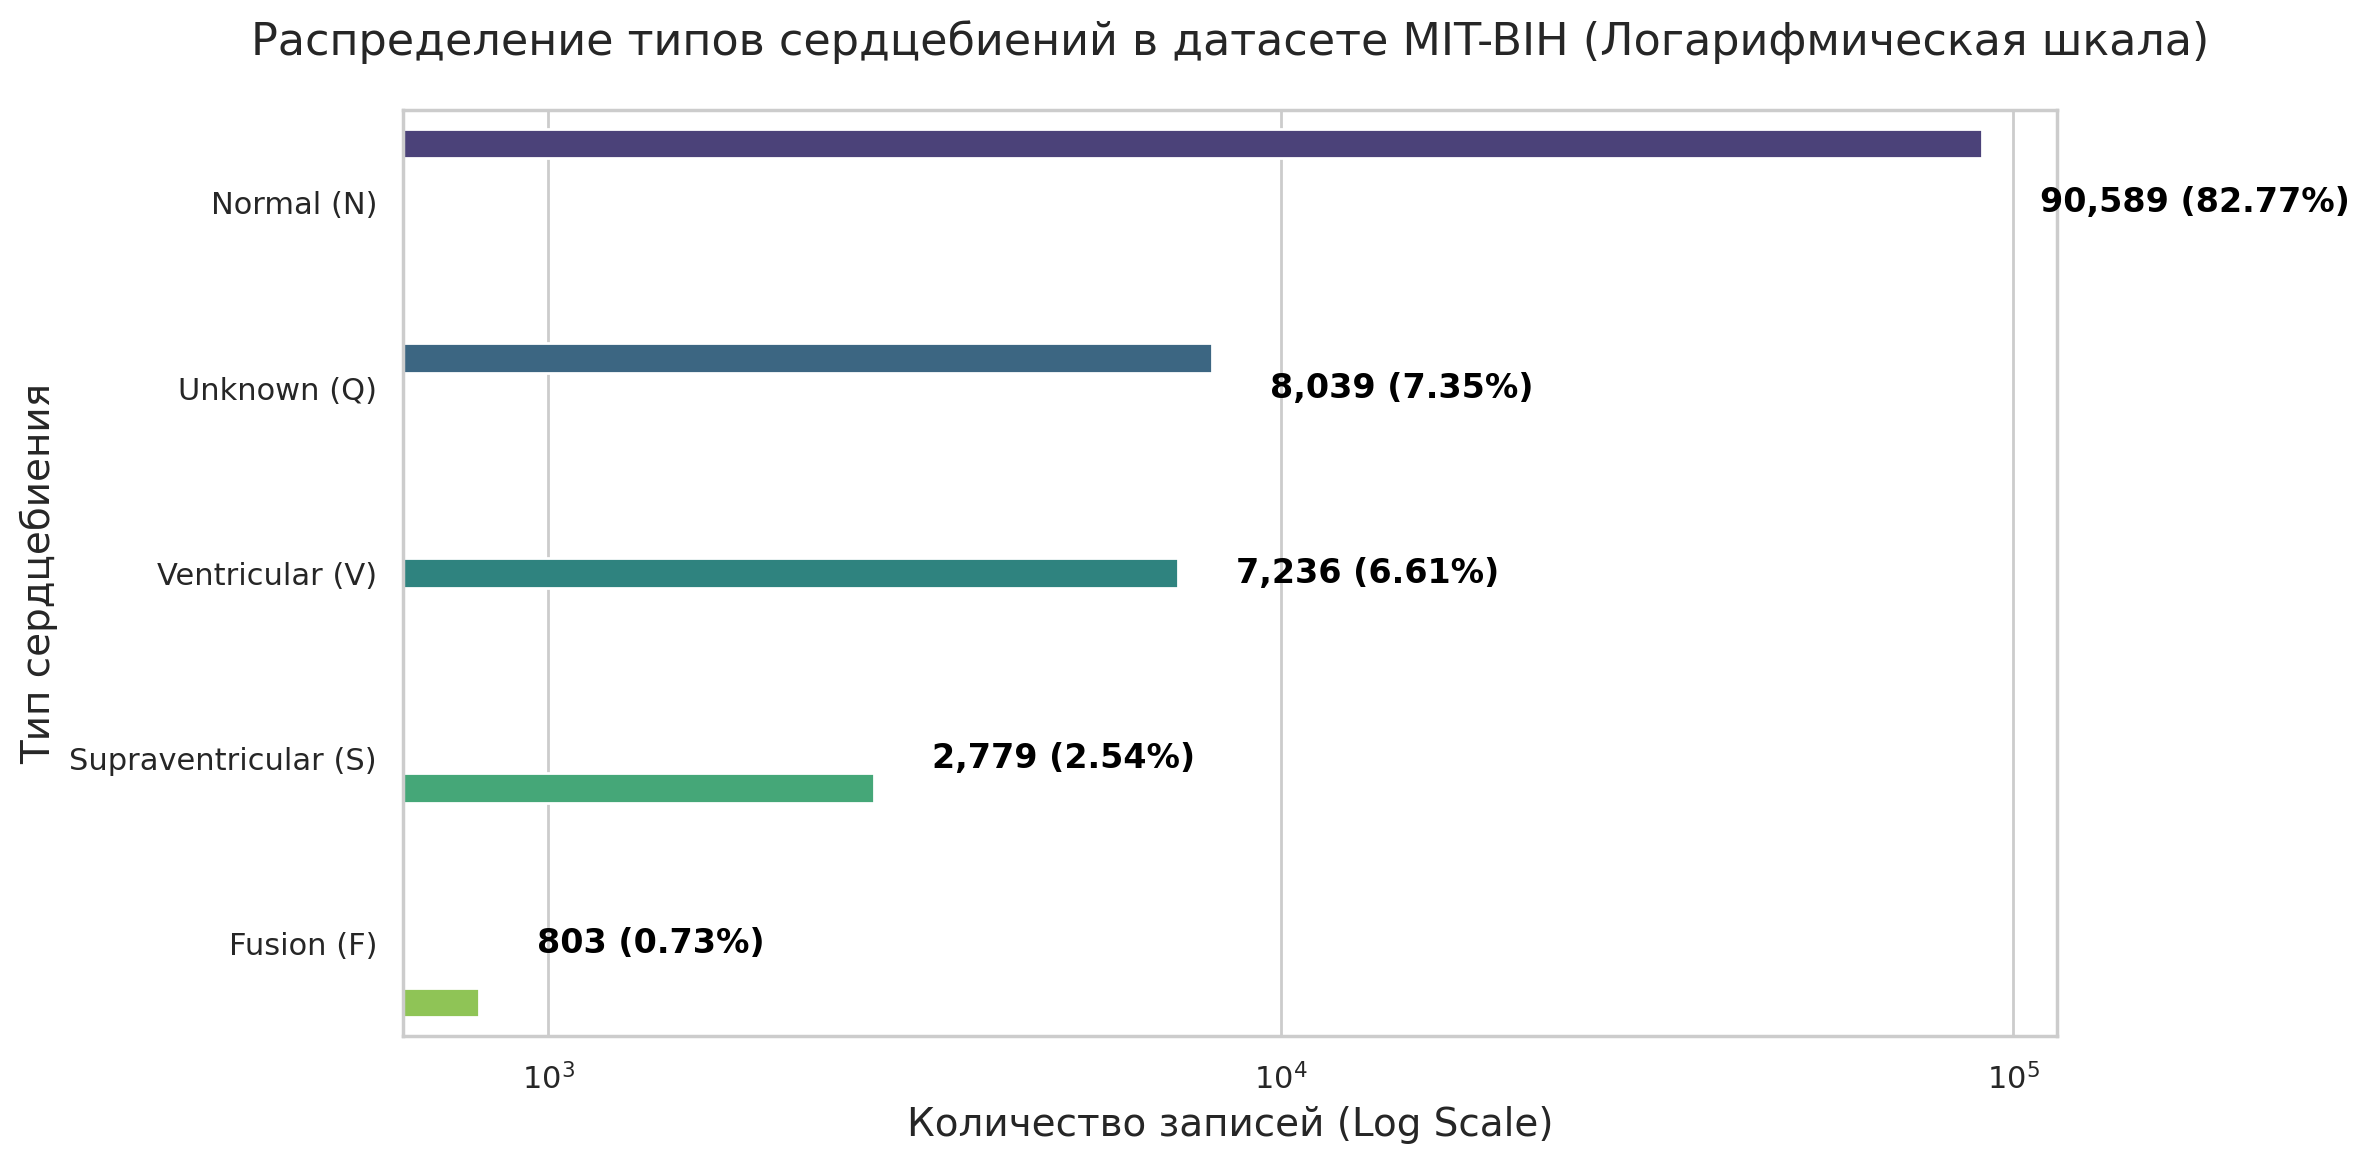

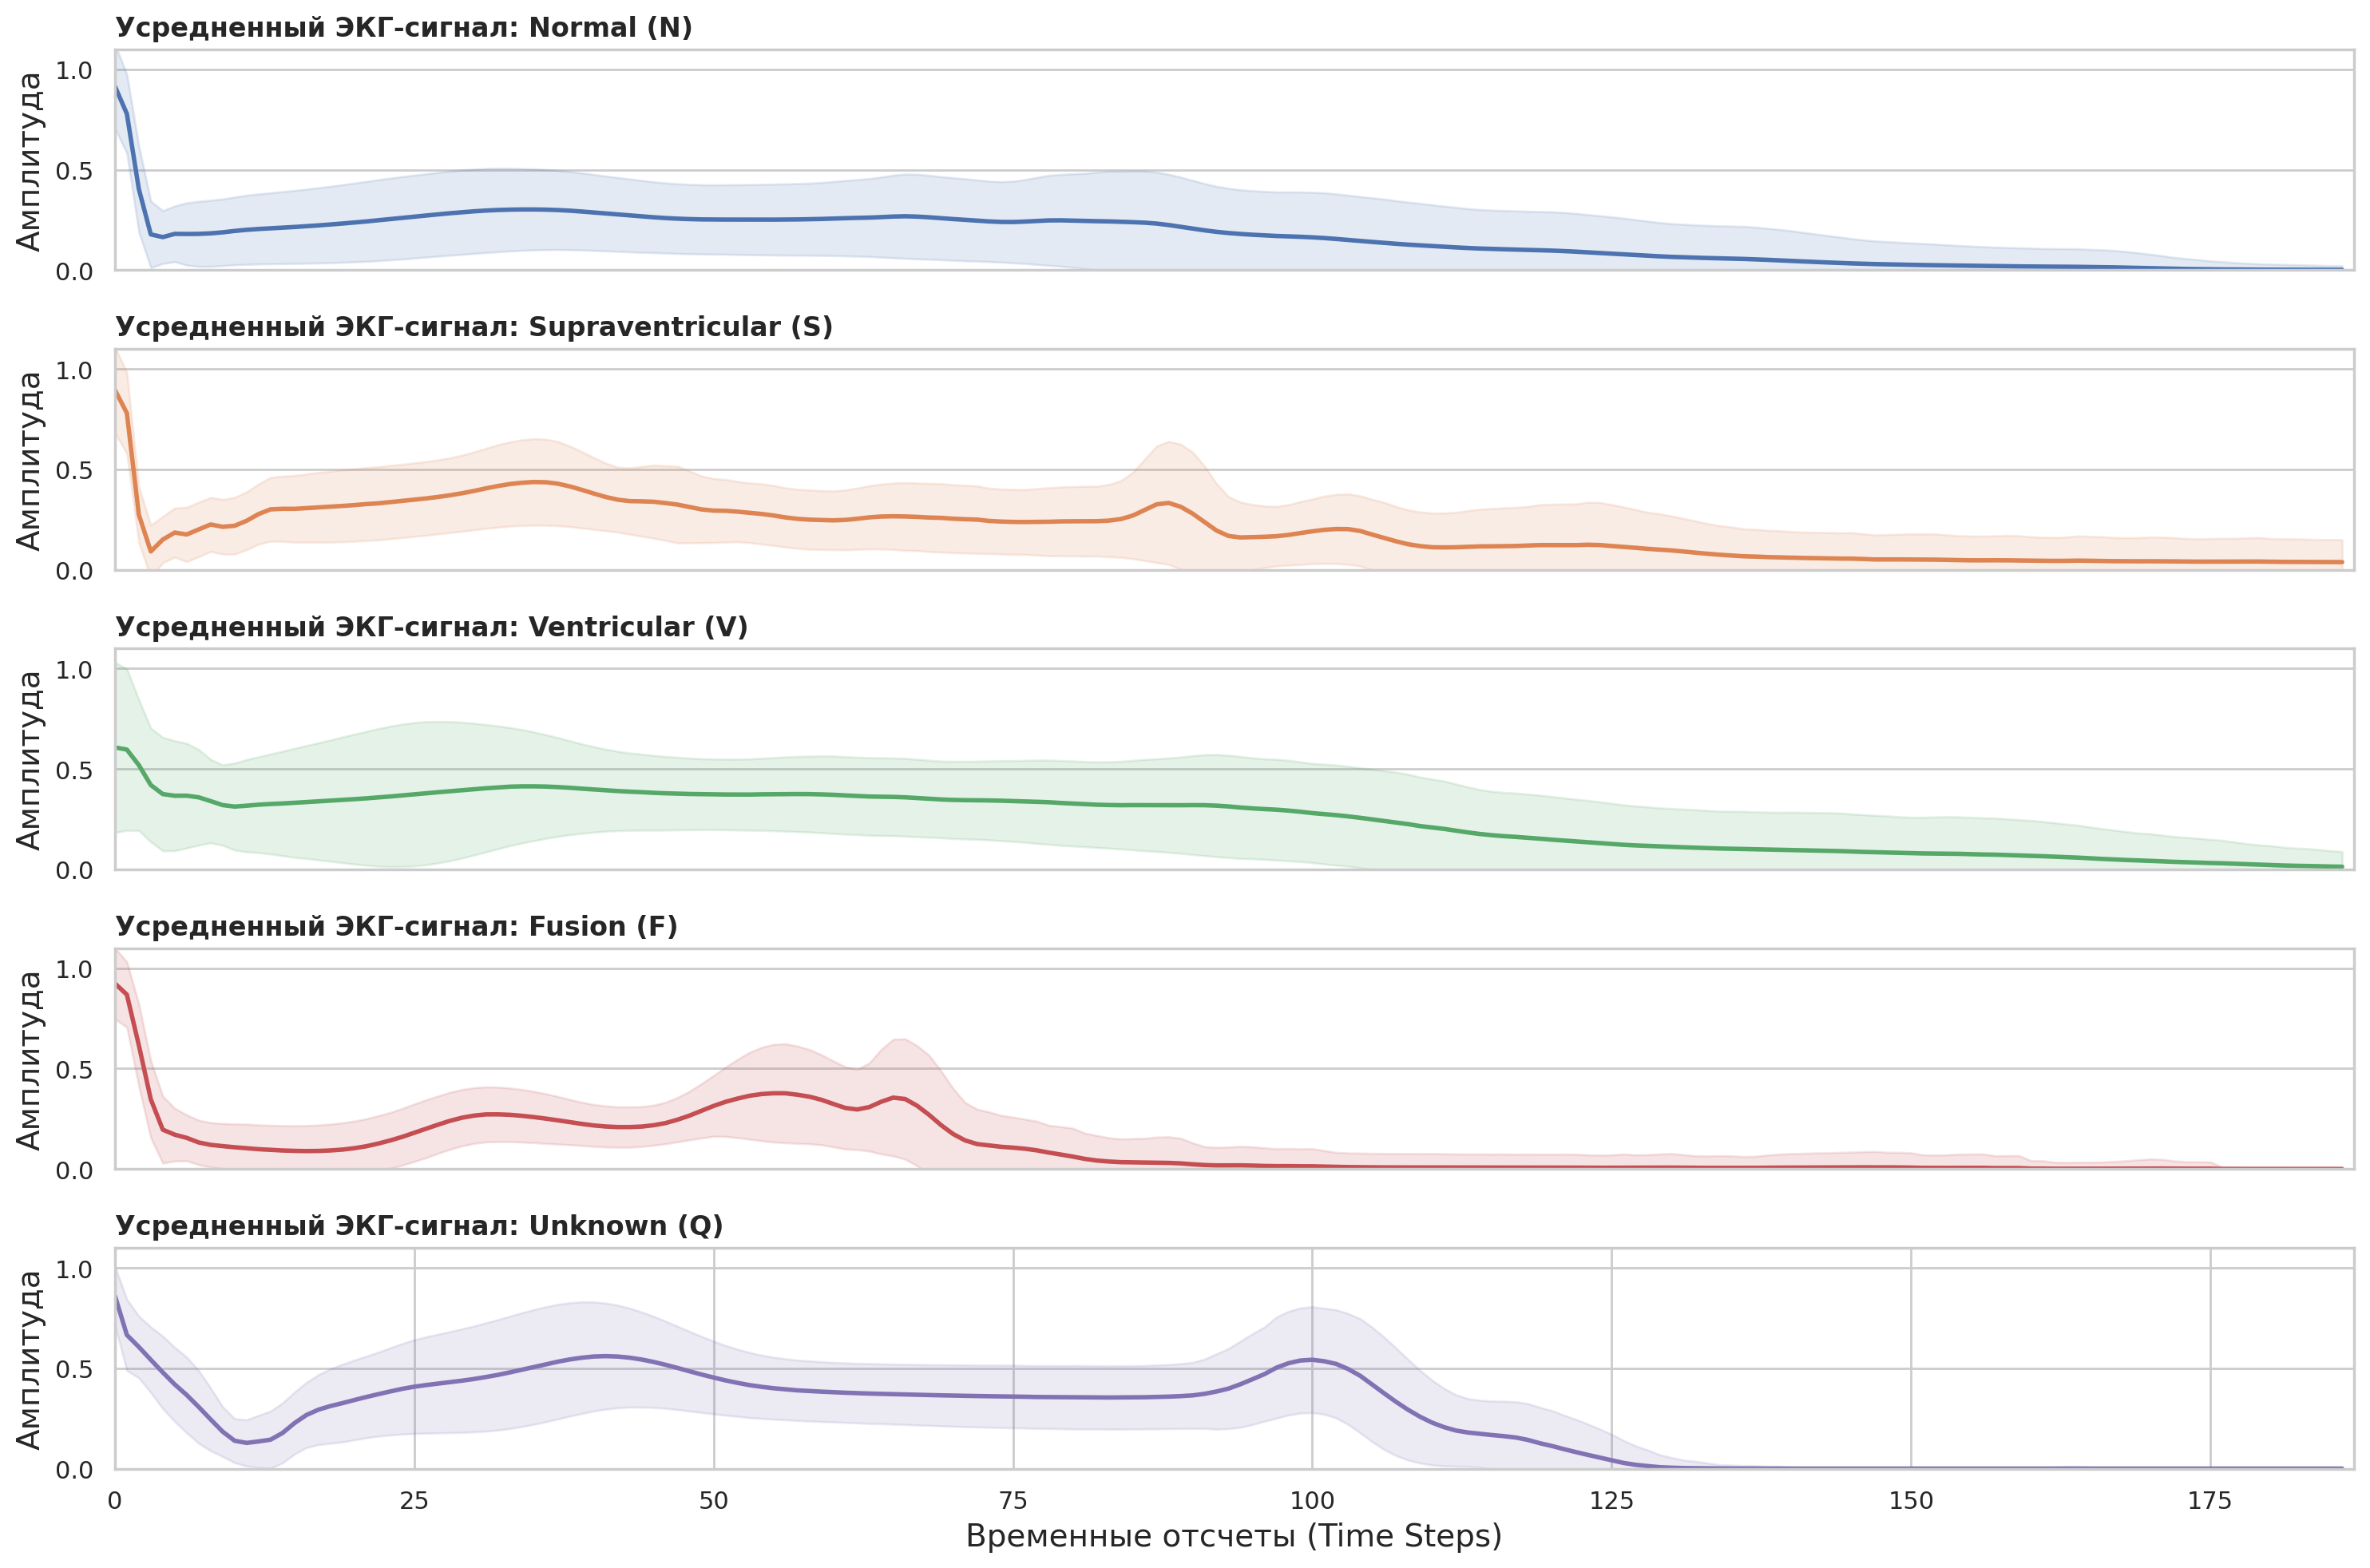

In [ ]:
# Словарь с расшифровкой классов
class_map = {
    0.0: 'Normal (N)',
    1.0: 'Supraventricular (S)',
    2.0: 'Ventricular (V)',
    3.0: 'Fusion (F)',
    4.0: 'Unknown (Q)'
}

full_df['class_name'] = full_df['target'].map(class_map)

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

# ГРАФИК 1: Распределение классов (Количество данных)
fig, ax = plt.subplots(figsize=(12, 6))

counts = full_df['class_name'].value_counts()
percentages = full_df['class_name'].value_counts(normalize=True) * 100

sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette="viridis", log=True, ax=ax)

if ax.get_legend() is not None:
    ax.get_legend().remove()
    
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    ax.text(count * 1.2, i, f"{count:,} ({pct:.2f}%)", va='center', weight='bold', color='black')

ax.set_title("Распределение типов сердцебиений в датасете MIT-BIH (Логарифмическая шкала)", pad=20)
ax.set_xlabel("Количество записей (Log Scale)")
ax.set_ylabel("Тип сердцебиения")
plt.tight_layout()
plt.show()


# ГРАФИК 2: Визуализация средних сигналов по каждому классу
time_columns = list(range(187))

plt.figure(figsize=(15, 10))

# Перебираем классы и строим для каждого график среднего сигнала и области отклонения
for idx, (cls_val, cls_name) in enumerate(class_map.items()):
    class_data = full_df[full_df['target'] == cls_val][time_columns]
    
    mean_signal = class_data.mean(axis=0)
    std_signal = class_data.std(axis=0)
    
    plt.subplot(5, 1, idx + 1)
    
    plt.fill_between(time_columns, mean_signal - std_signal, mean_signal + std_signal, alpha=0.15, color=f"C{idx}")
    plt.plot(time_columns, mean_signal, label=cls_name, color=f"C{idx}", linewidth=2)
    
    plt.title(f"Усредненный ЭКГ-сигнал: {cls_name}", loc='left', fontsize=12, weight='bold')
    plt.xlim(0, 187)
    plt.ylim(0, 1.1)
    plt.ylabel("Амплитуда")
    if idx < 4:
        plt.xticks([])

plt.xlabel("Временные отсчеты (Time Steps)")
plt.tight_layout()
plt.show()

## Архитектура

LSTM-автоэнкодер

In [6]:
class Encoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(Encoder, self).__init__()
        self.seq_len, self.n_features = seq_len, n_features
        self.embedding_dim, self.hidden_dim = embedding_dim, 2 * embedding_dim

        self.rnn1 = nn.LSTM(input_size=n_features, hidden_size=self.hidden_dim, num_layers=1, batch_first=True)
        self.rnn2 = nn.LSTM(input_size=self.hidden_dim, hidden_size=embedding_dim, num_layers=1, batch_first=True)

    def forward(self, x):
        x, (_, _) = self.rnn1(x)
        x, (hidden_n, _) = self.rnn2(x)
        return hidden_n

In [ ]:
class Decoder(nn.Module):
    def __init__(self, seq_len, input_dim=64, n_features=1):
        super(Decoder, self).__init__()
        self.seq_len, self.input_dim = seq_len, input_dim
        self.hidden_dim, self.n_features = 2 * input_dim, n_features

        self.rnn1 = nn.LSTM(input_size=input_dim, hidden_size=input_dim, num_layers=1, batch_first=True)
        self.rnn2 = nn.LSTM(input_size=input_dim, hidden_size=self.hidden_dim, num_layers=1, batch_first=True)
        self.output_layer = nn.Linear(self.hidden_dim, n_features)

    def forward(self, x):
        x = x.permute(1, 0, 2)
        x = x.repeat(1, self.seq_len, 1)

        x, _ = self.rnn1(x)
        x, _ = self.rnn2(x)
        return self.output_layer(x)

Итоговый модуль автоэнкодера:

In [8]:
class RecurrentAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(RecurrentAutoencoder, self).__init__()
        self.encoder = Encoder(seq_len, n_features, embedding_dim).to(device)
        self.decoder = Decoder(seq_len, embedding_dim, n_features).to(device)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

Экземпляр автокодировщика


In [8]:
model = RecurrentAutoencoder(seq_len, n_features, embedding_dim=64).to(device)

## Обучение

Напишем вспомогательную функцию для процесса обучения:

In [ ]:
def train_model(model, train_loader, val_loader, n_epochs=30):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.L1Loss(reduction='sum').to(device)
    history = dict(train=[], val=[])

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = np.inf

    for epoch in range(1, n_epochs + 1):
        model = model.train()
        train_losses = []

        for seq_true in train_loader:
            optimizer.zero_grad()
            seq_true = seq_true.to(device)
            seq_pred = model(seq_true)

            loss = criterion(seq_pred, seq_true)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item() / seq_true.shape[0])

        val_losses = []
        model = model.eval()
        with torch.no_grad():
            for seq_true in val_loader:
                seq_true = seq_true.to(device)
                seq_pred = model(seq_true)
                loss = criterion(seq_pred, seq_true)
                val_losses.append(loss.item() / seq_true.shape[0])

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)

        history['train'].append(train_loss)
        history['val'].append(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f'Epoch {epoch}: train loss {train_loss:.4f} val loss {val_loss:.4f}')

    model.load_state_dict(best_model_wts)
    return model.eval(), history


In [ ]:
# Запускаем обучение
model, history = train_model(model, train_loader, val_loader, n_epochs=30)

Epoch 1: train loss 28.8425 val loss 28.5278
Epoch 2: train loss 28.4425 val loss 27.3828
Epoch 3: train loss 27.8040 val loss 27.0960
Epoch 4: train loss 27.3063 val loss 28.9647
Epoch 5: train loss 22.1857 val loss 20.3407
Epoch 6: train loss 20.1183 val loss 20.3797
Epoch 7: train loss 19.9544 val loss 20.2424
Epoch 8: train loss 19.8755 val loss 19.7427
Epoch 9: train loss 19.8329 val loss 19.9354
Epoch 10: train loss 19.8016 val loss 19.6589
Epoch 11: train loss 19.7775 val loss 19.6342
Epoch 12: train loss 19.7331 val loss 19.6170
Epoch 13: train loss 19.7396 val loss 19.6748
Epoch 14: train loss 19.7598 val loss 19.5415
Epoch 15: train loss 15.9801 val loss 12.9465
Epoch 16: train loss 12.3384 val loss 12.2751
Epoch 17: train loss 9.2879 val loss 8.6877
Epoch 18: train loss 8.3991 val loss 7.6369
Epoch 19: train loss 7.5802 val loss 7.2563
Epoch 20: train loss 7.3197 val loss 7.2697
Epoch 21: train loss 7.1126 val loss 6.8460
Epoch 22: train loss 6.9825 val loss 6.5219
Epoch 23:

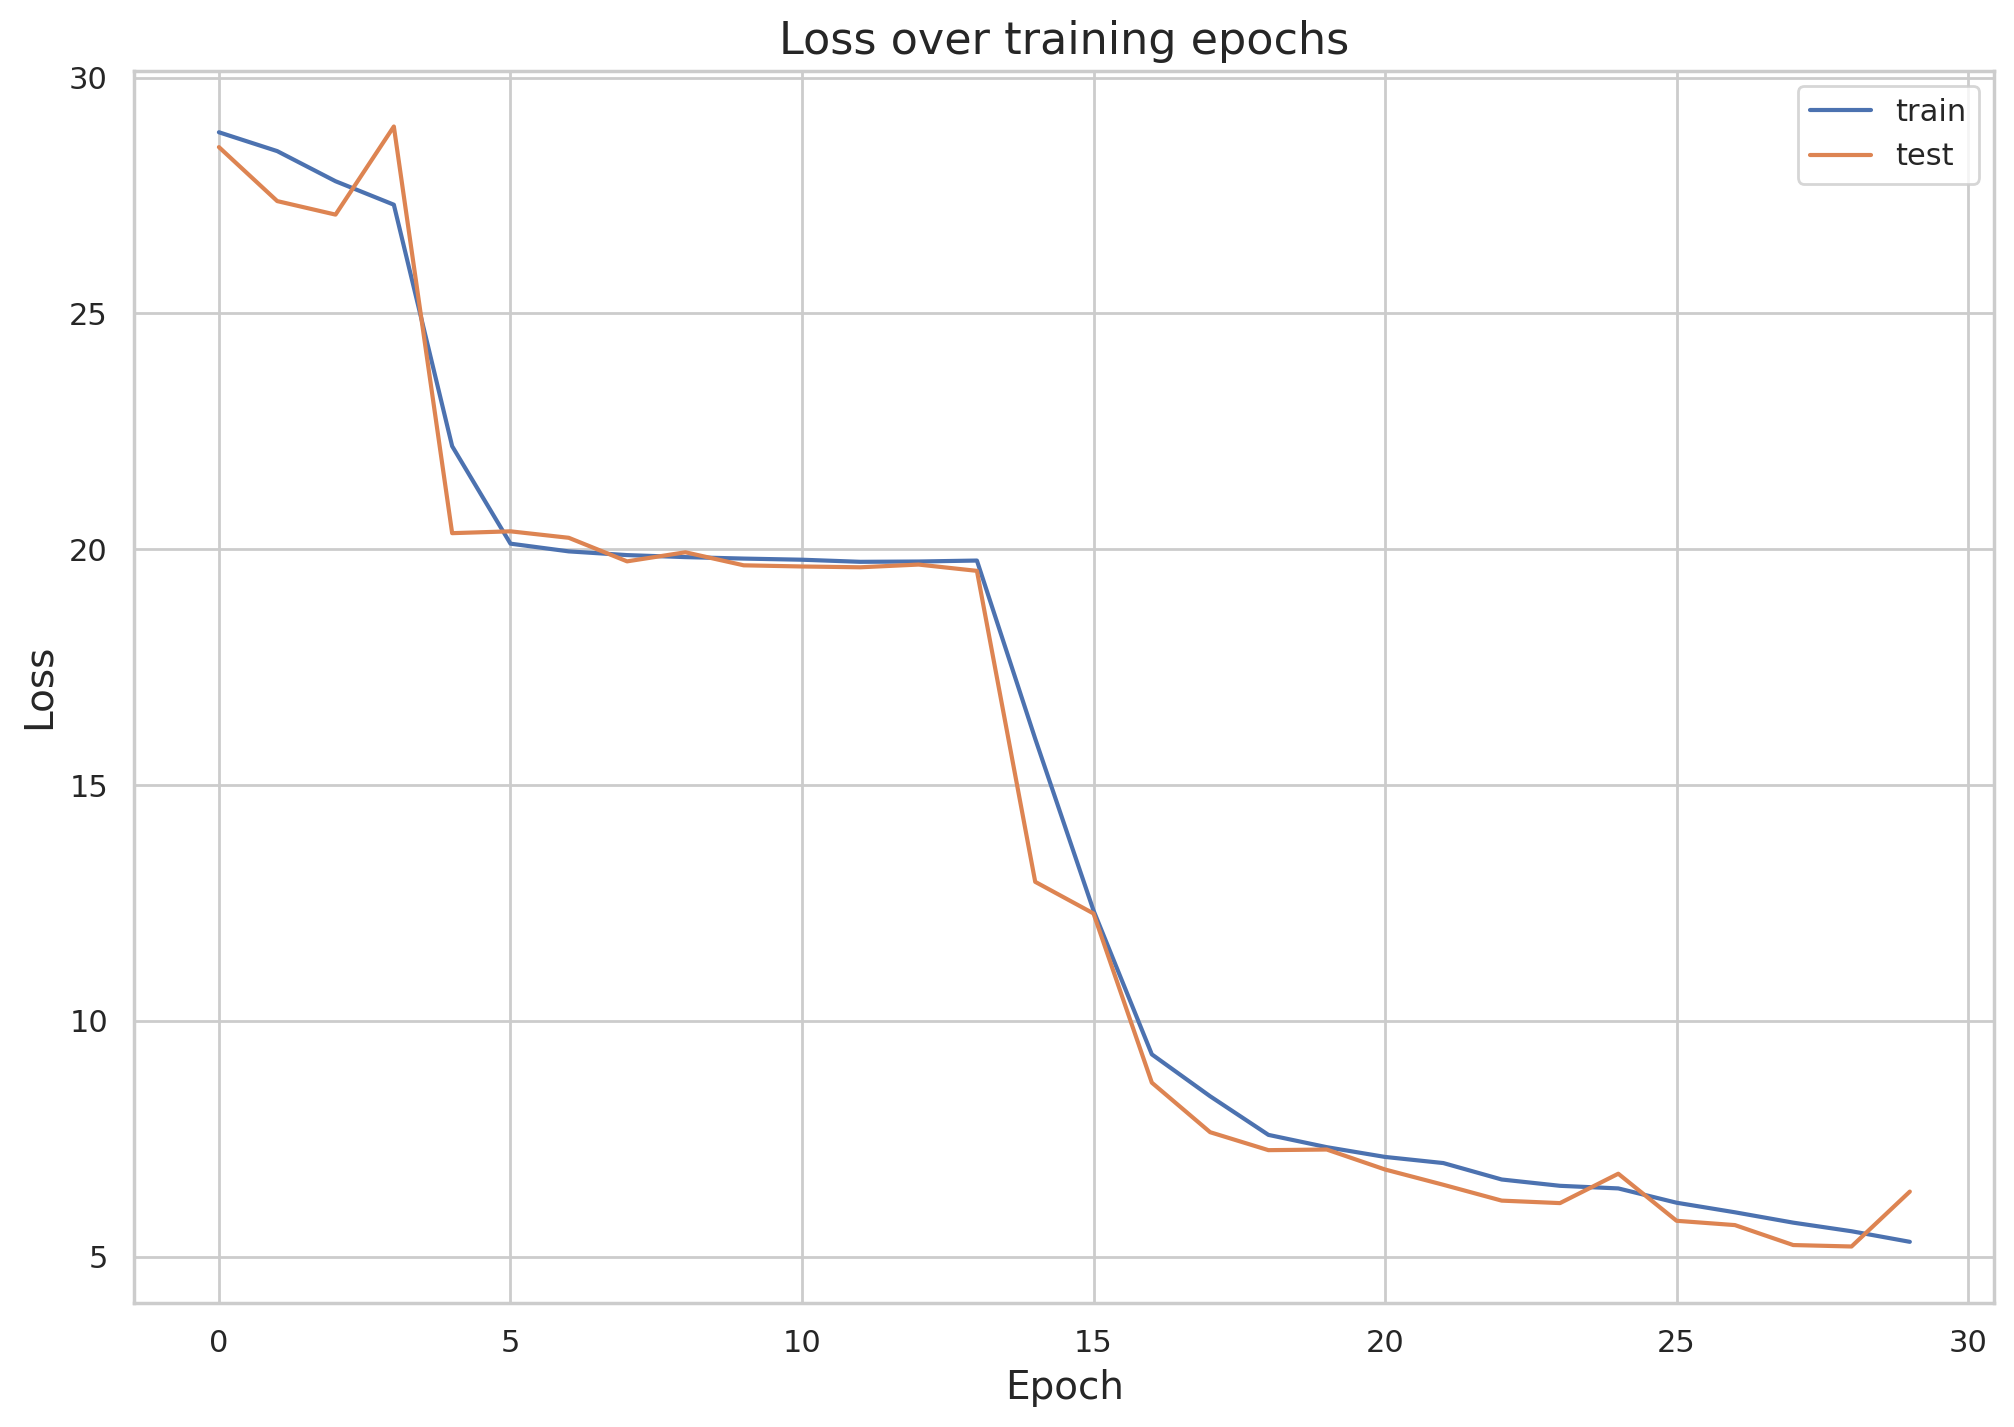

In [23]:
ax = plt.figure().gca()

ax.plot(history['train'])
ax.plot(history['val'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'test'])
plt.title('Loss over training epochs')
plt.show()

## Сохранение модели
Сохраним модель для последующего использования:

In [24]:
MODEL_PATH = 'model.pth'

torch.save(model, MODEL_PATH)

## Выбор порогового значения
Имея модель, можем взглянуть на ошибку реконструкции на обучающем наборе. Вспомогательная функция для получения предсказаний модели:

In [10]:
def predict(model, dataloader):
  predictions, losses = [], []
  criterion = nn.L1Loss(reduction='sum').to(device)
    
  with torch.no_grad():
    model = model.eval()
    for seq_true in dataloader:
      seq_true = seq_true.to(device)
      seq_pred = model(seq_true)

      loss = criterion(seq_pred, seq_true)

      predictions.append(seq_pred.cpu().numpy().flatten())
      losses.append(loss.item())
  return predictions, losses

/tmp/ipykernel_35/4132463477.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(losses, bins=50, kde=True);
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


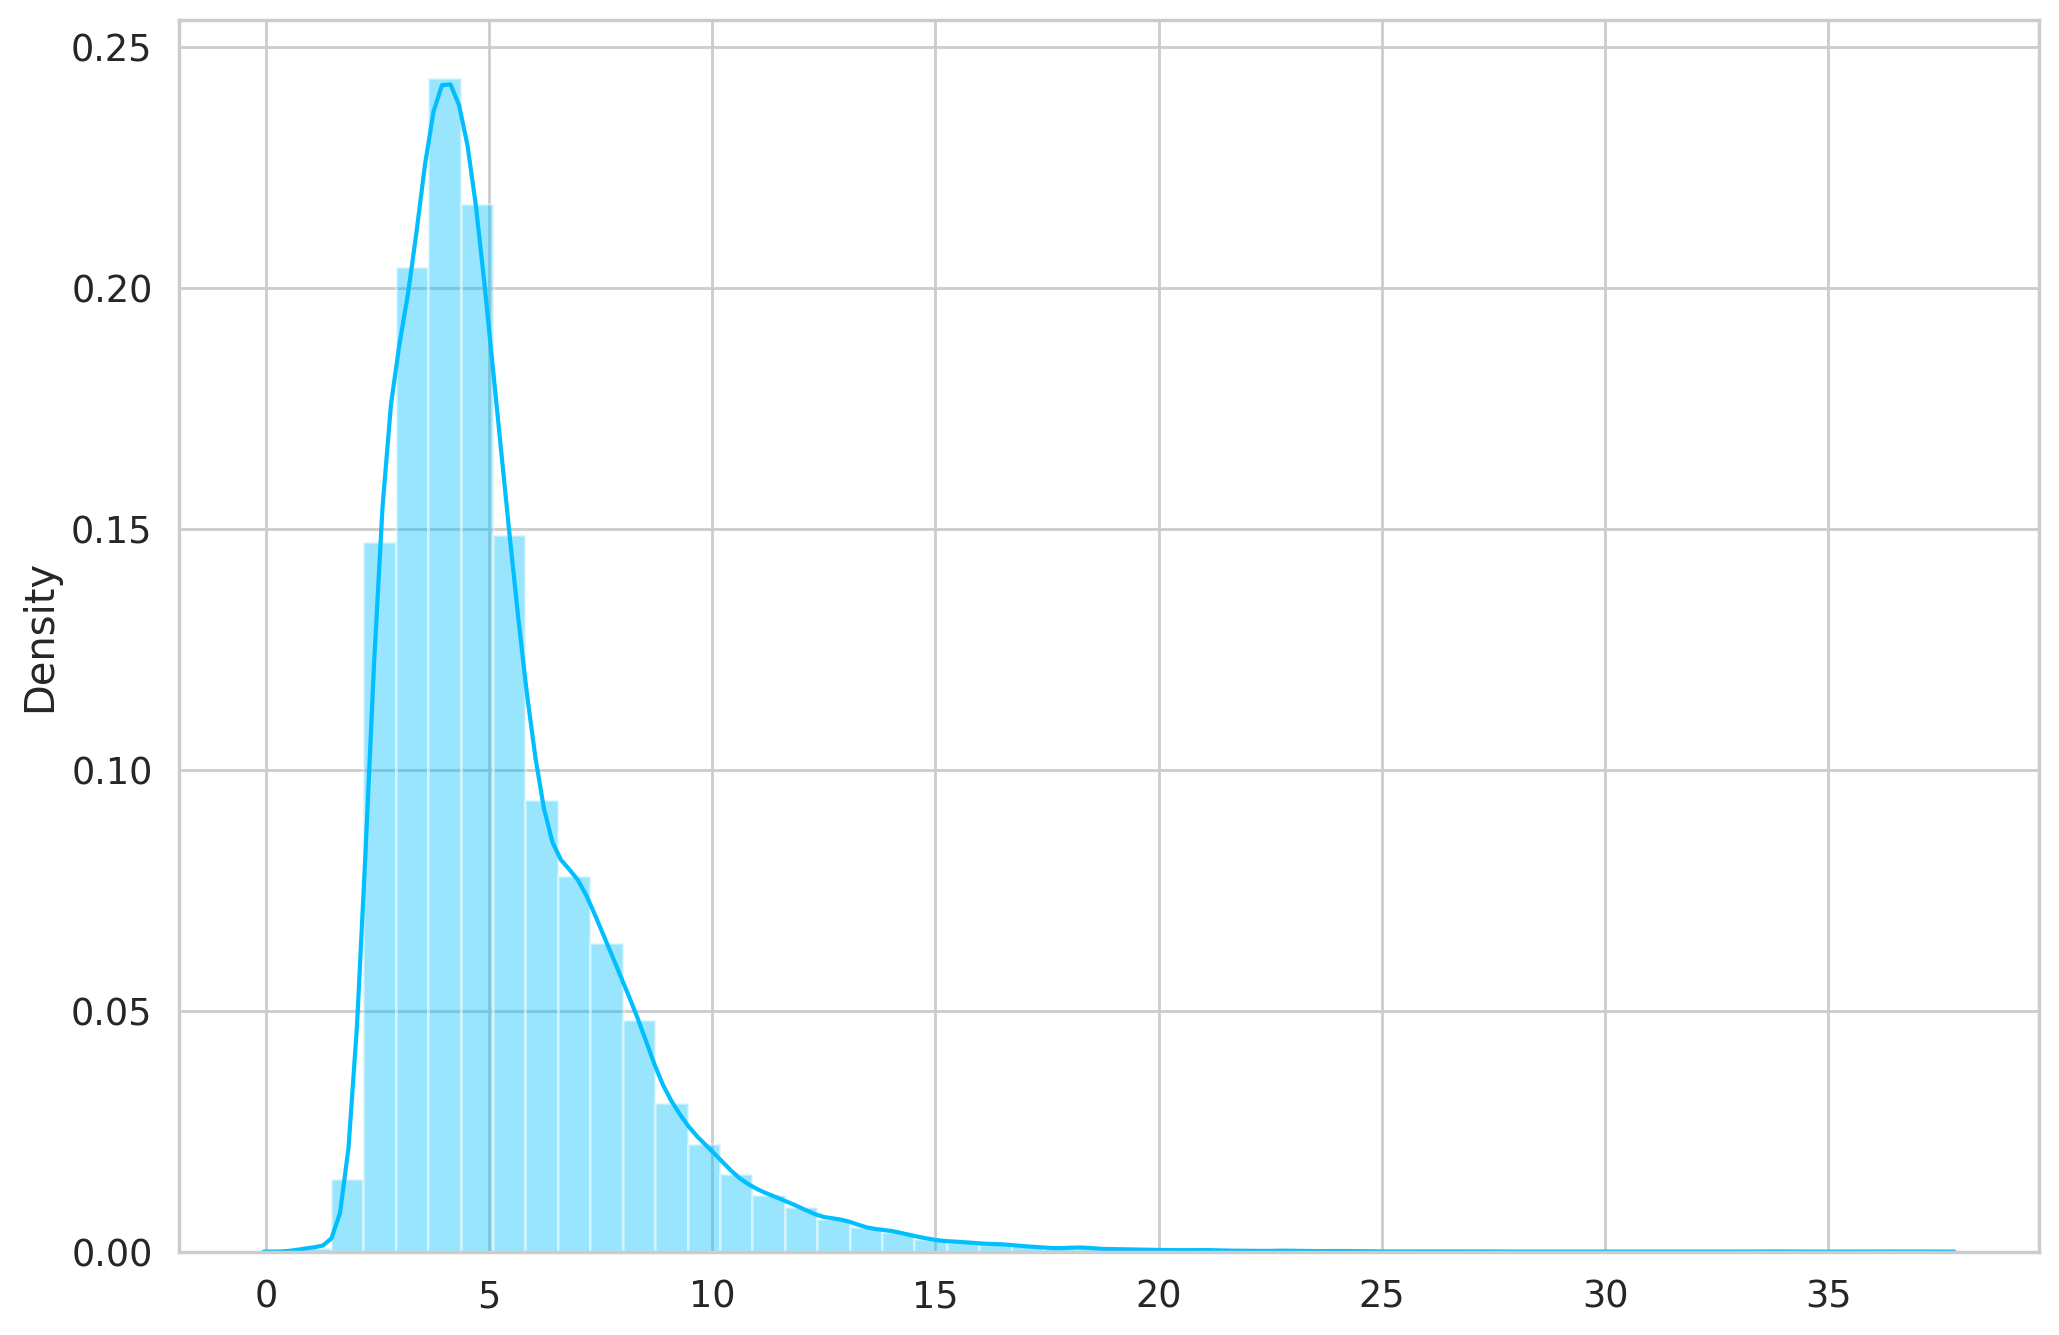

In [ ]:
# Создадим отдельный dataloader, загружающий один пример, чтобы оценить MAE на единичном сигнале, а не на батче
train_loader_one_element = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True
)

_, losses = predict(model, train_loader_one_element)

sns.distplot(losses, bins=50, kde=True);

In [19]:
THRESHOLD = 7

## Оценка
Используя пороговое значение, можно переформулировать проблему в простую задачу бинарной классификации:

- Если ошибка реконструкции для примера ниже порогового значения, мы классифицируем его как *нормальное* сердцебиение
- Если ошибка выше порогового значения, мы классифицируем его как *аномалию*

## Нормальные сердцебиения
Проверяем, насколько хорошо модель справляется с нормальными сердцебиениями. Используем нормальные сердцебиения из тестового набора:

/tmp/ipykernel_35/1135353705.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pred_losses, bins=50, kde=True);
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


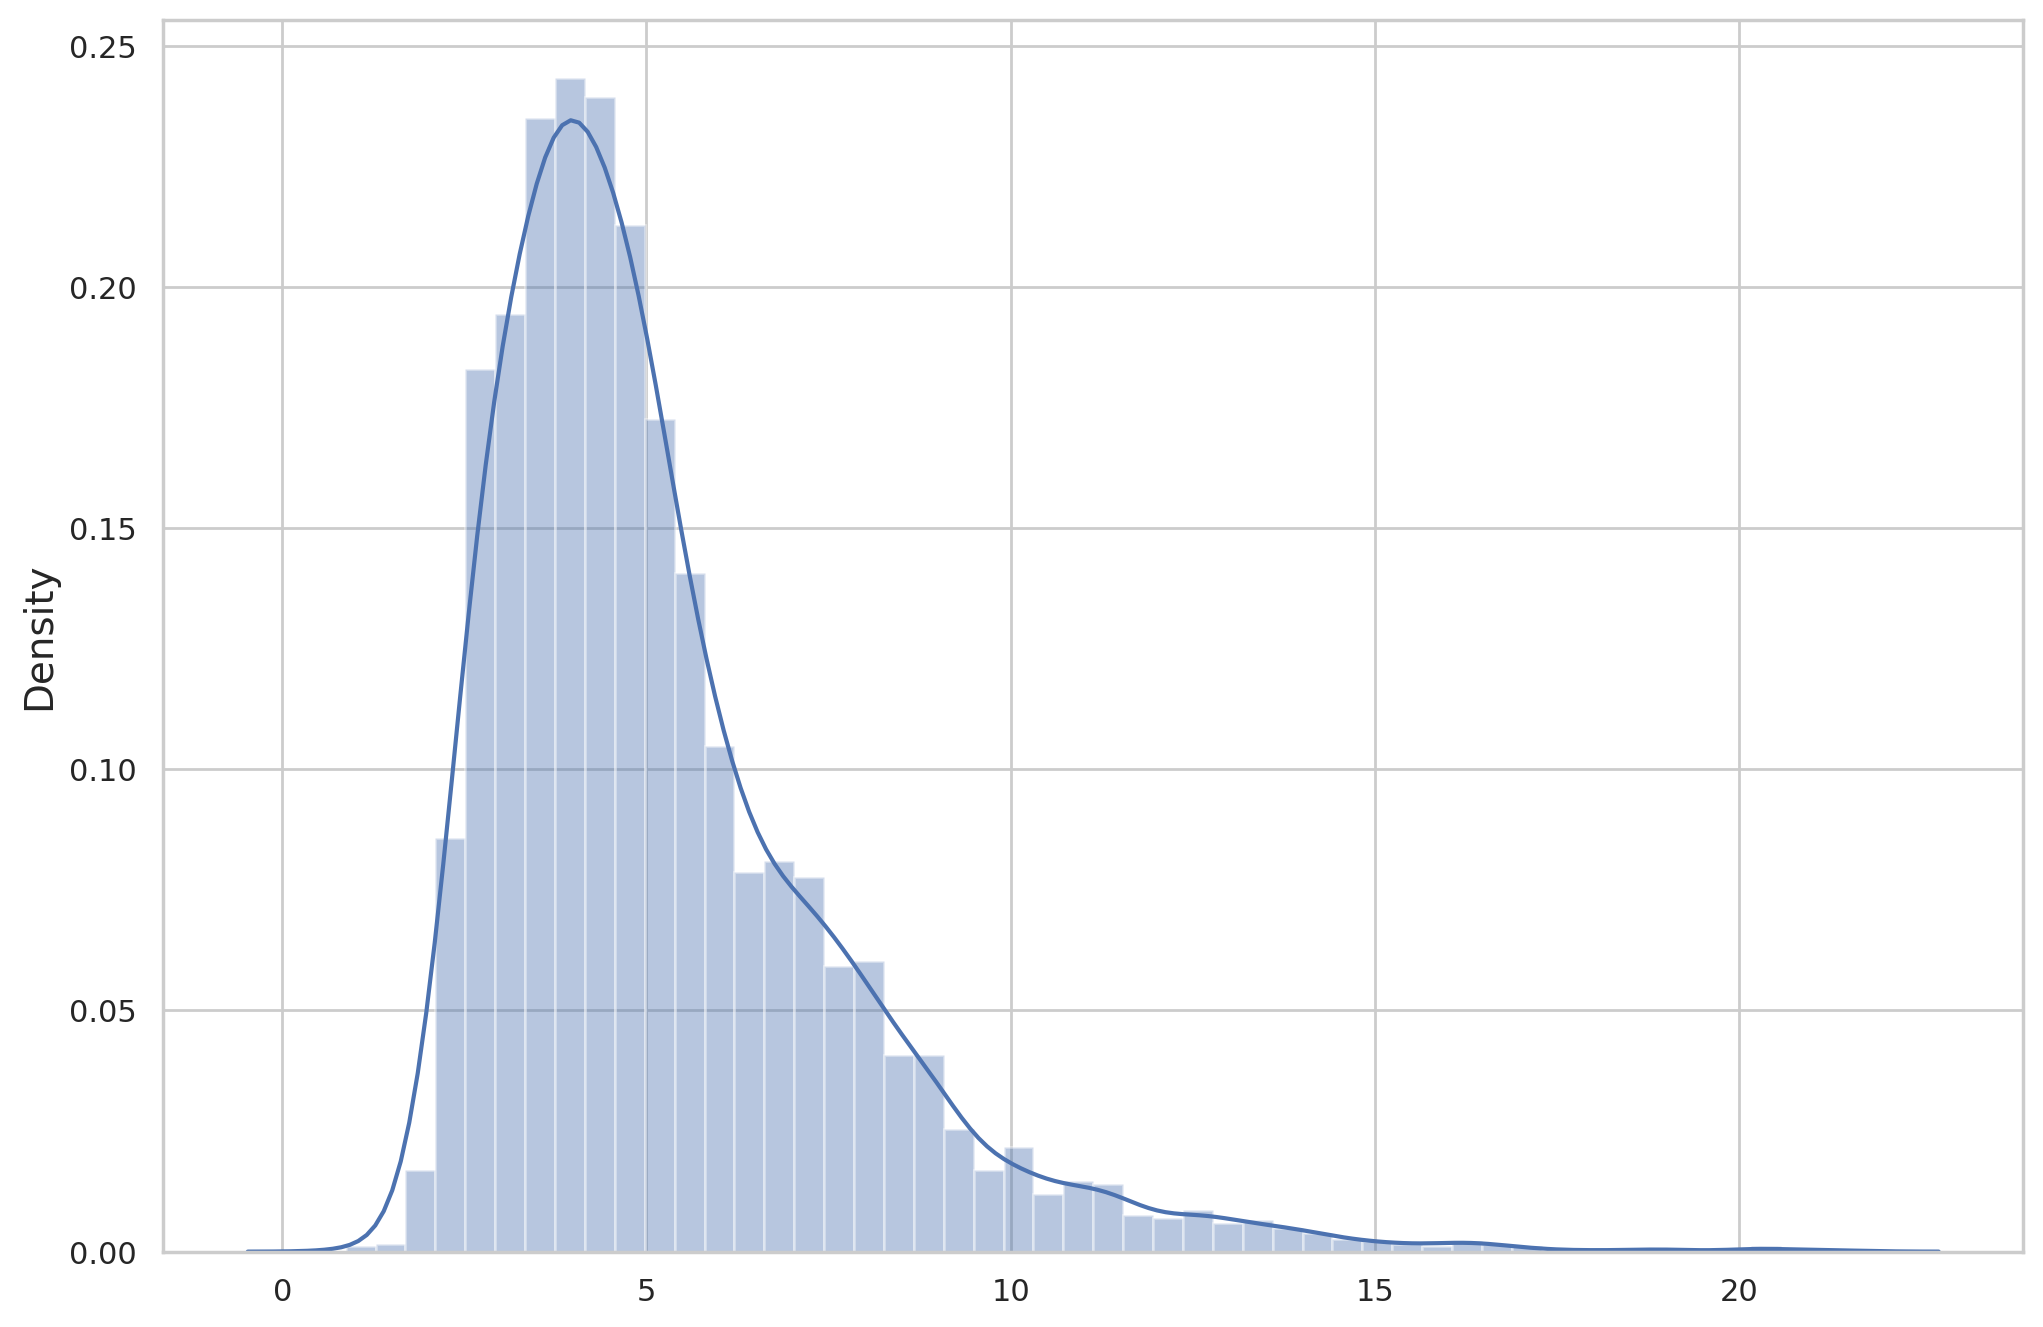

In [11]:
# Загрузчик test_normal_loader загружает по одному сигналу
predictions, pred_losses = predict(model, test_normal_loader)
sns.distplot(pred_losses, bins=50, kde=True);

Посчитаем правильные предсказания:

In [20]:
correct = sum(l <= THRESHOLD for l in pred_losses)
print(f'Correct normal predictions: {correct}/{len(test_normal_loader)}')

Correct normal predictions: 3659/4485


### Аномалии

Сделаем то же самое с примерами аномалий, но их количество намного больше. Возьмем подмножество, которое имеет тот же размер, что и нормальные сердцебиения:

In [15]:
anomaly_dataset = test_anomaly_dataset[:len(test_normal_dataset)]

anomaly_loader = DataLoader(
    anomaly_dataset,
    batch_size=1,
    shuffle=False
)

Теперь мы можем получить предсказания нашей модели для подмножества аномалий:

In [ ]:
predictions, pred_losses_anomaly = predict(model, anomaly_loader)

/tmp/ipykernel_35/1558635325.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pred_losses_anomaly, bins=50, kde=True);
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


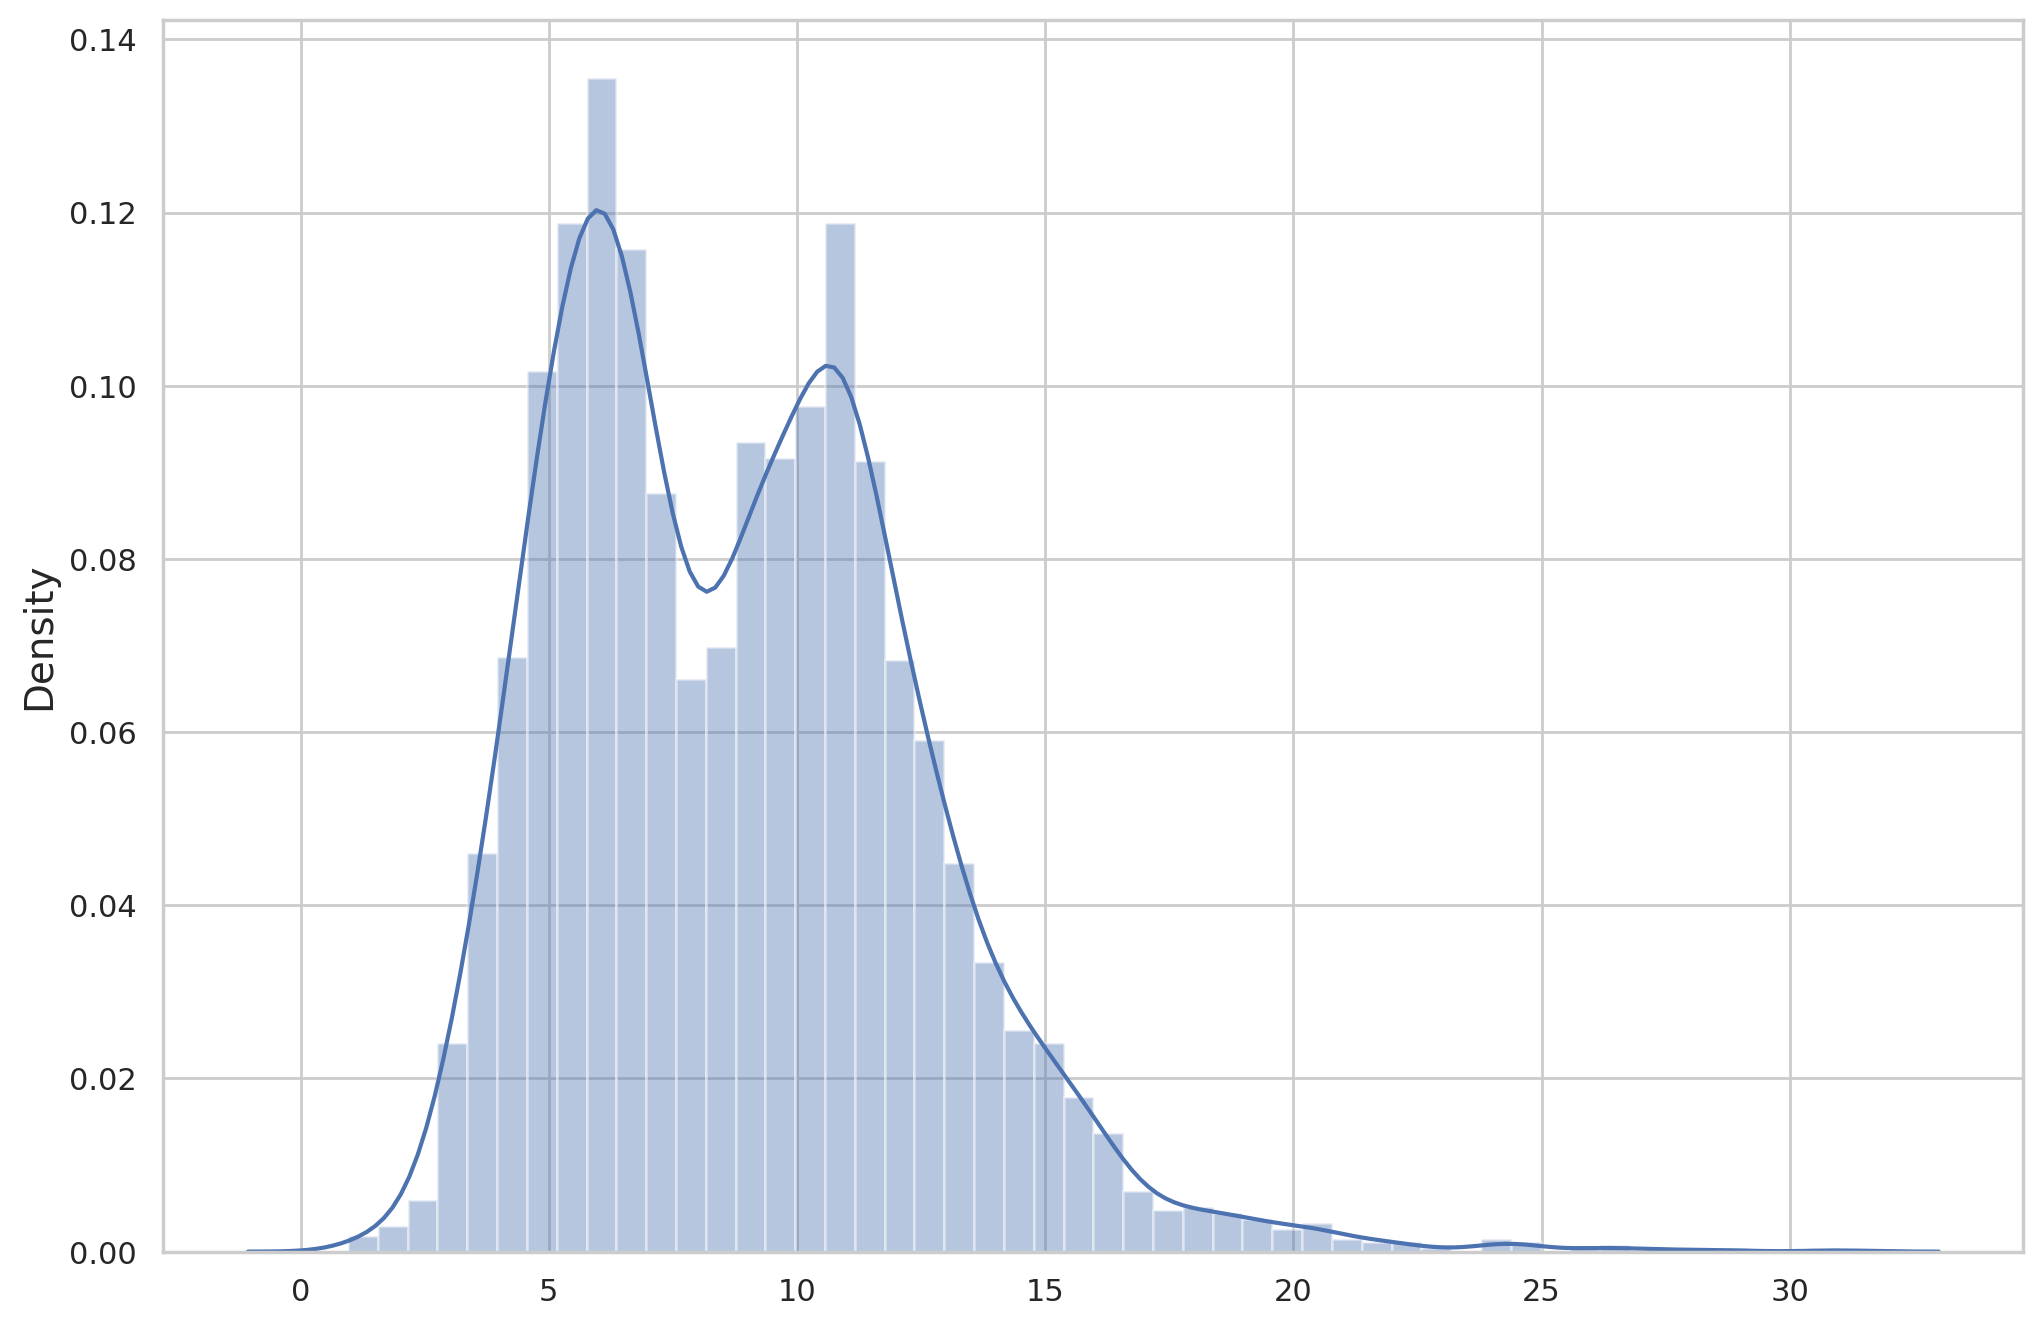

In [18]:
sns.distplot(pred_losses_anomaly, bins=50, kde=True);

Наконец, подсчитаем количество примеров, превышающих порог (рассматриваемых как аномалии):

In [21]:
correct = sum(l > THRESHOLD for l in pred_losses_anomaly)
print(f'Correct anomaly predictions: {correct}/{len(anomaly_loader)}')

Correct anomaly predictions: 2794/4485


Много сигналов, распознаваемых моделью как норма. На гистограмме заметны 2 пика, можно предположить, что они соответствуют разным заболеваниям. Проверим, каковы распределения ошибок реконструкции среди различных заболеваний.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

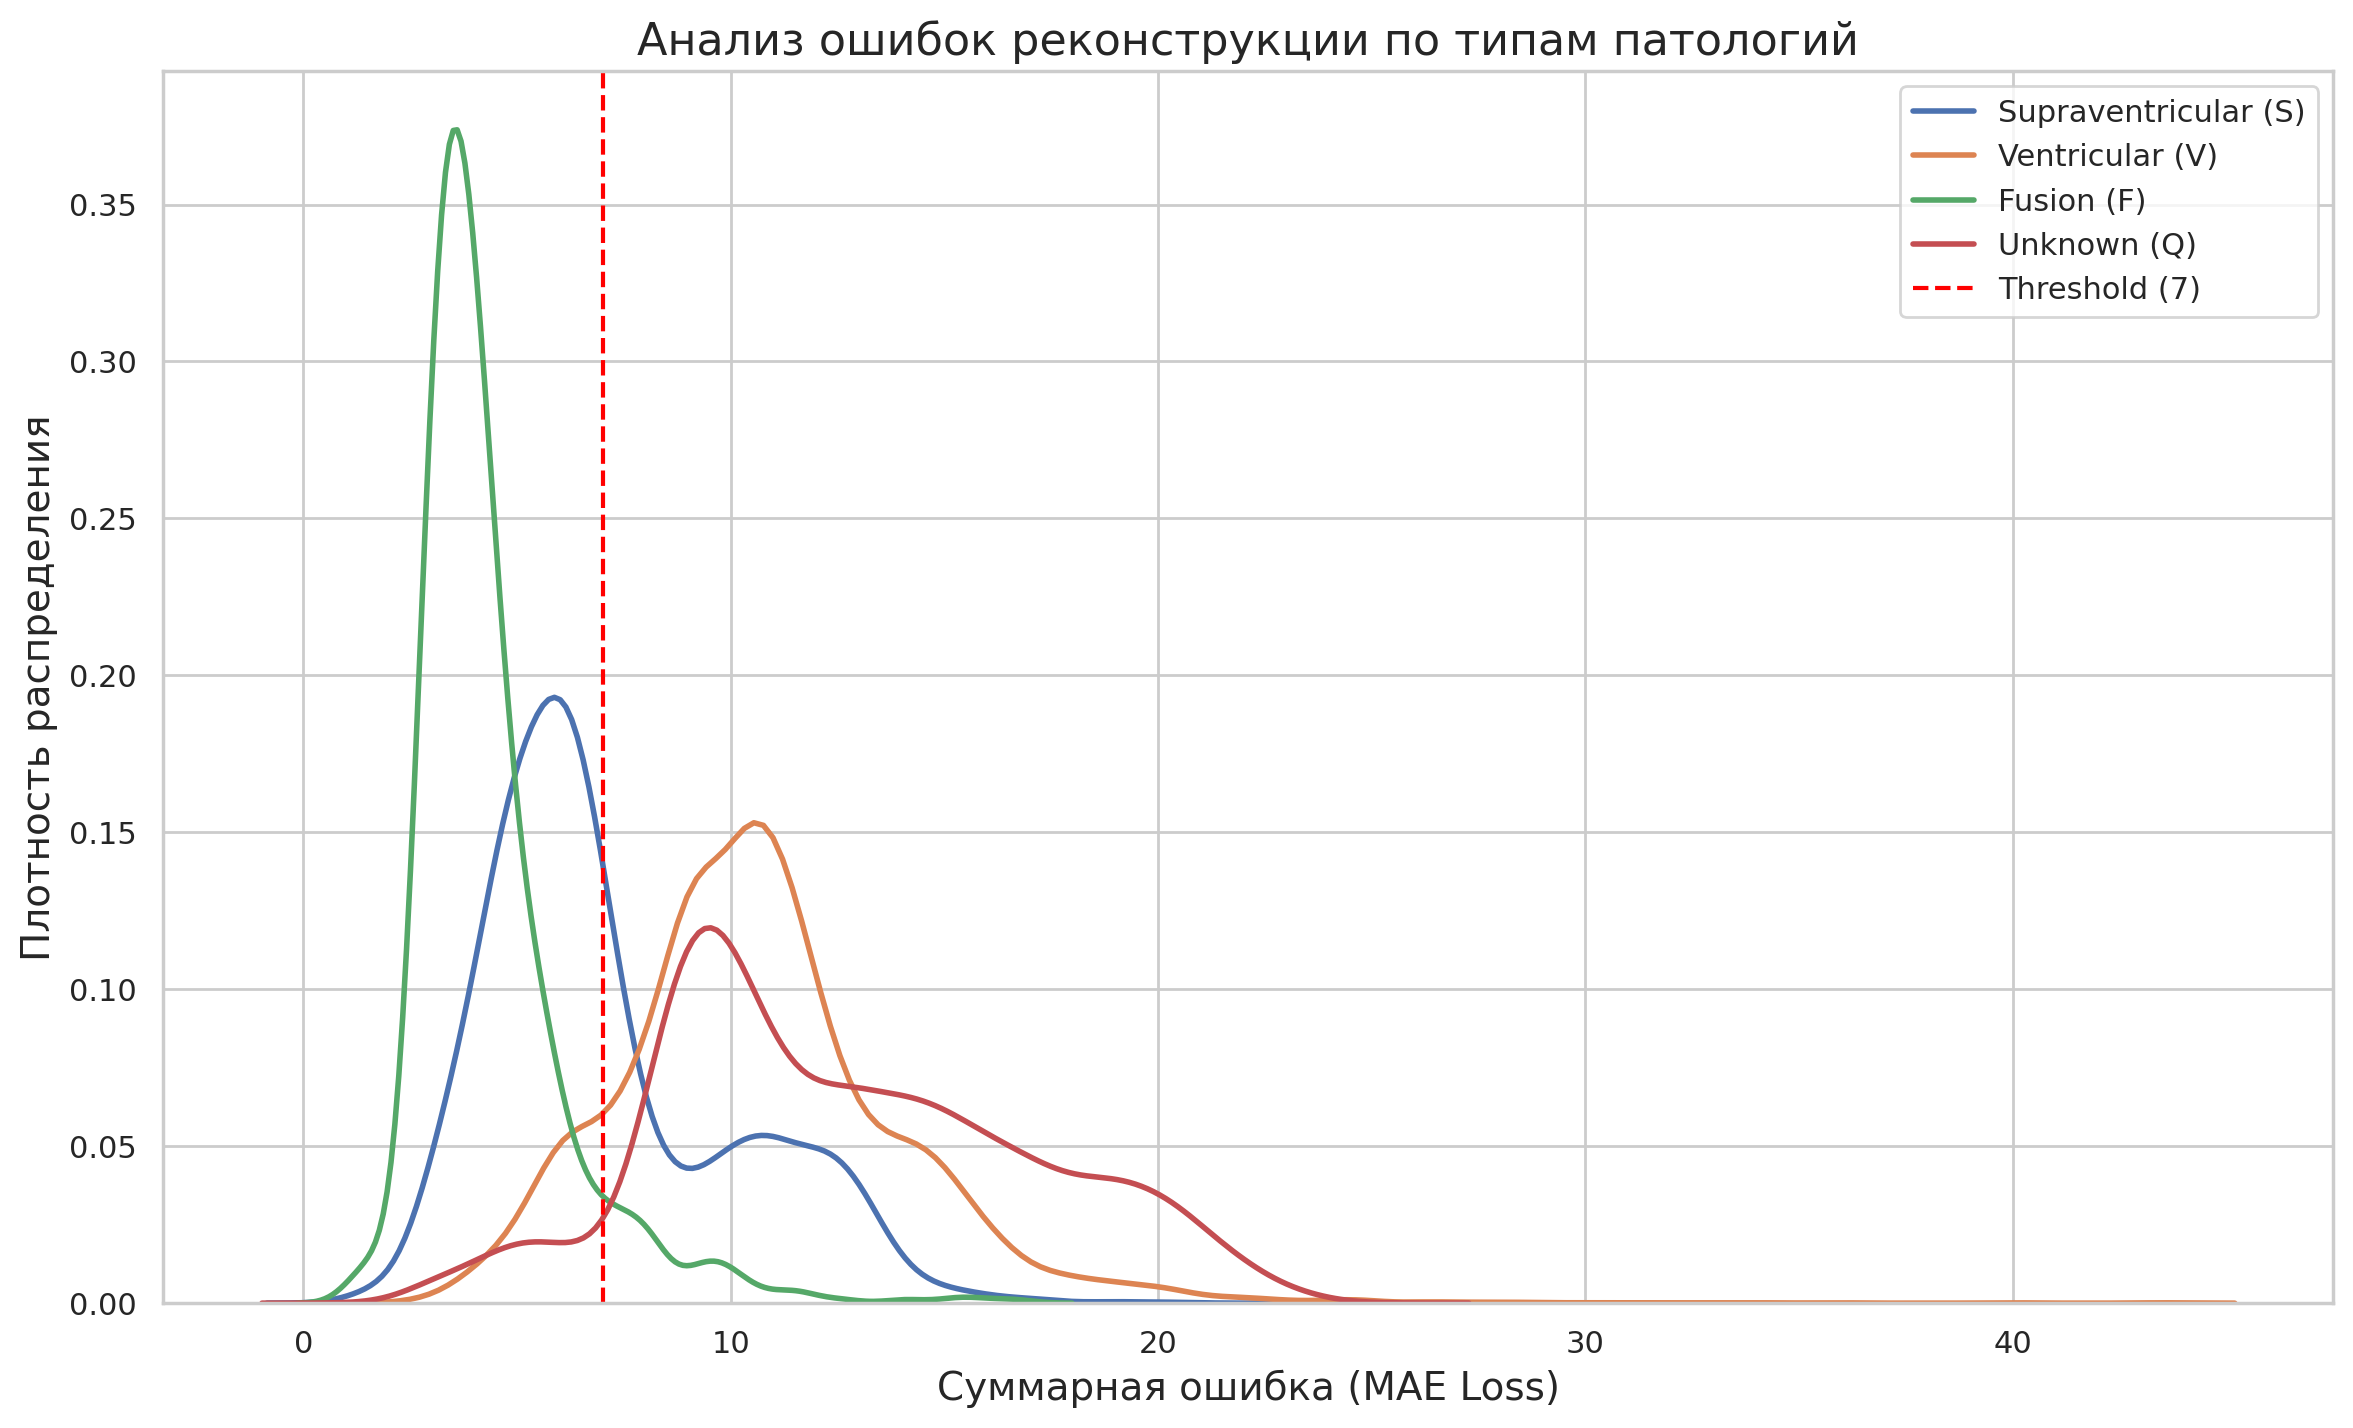

In [ ]:
# Названия классов для легенды
anomaly_classes = {
    1.0: 'Supraventricular (S)',
    2.0: 'Ventricular (V)',
    3.0: 'Fusion (F)',
    4.0: 'Unknown (Q)'
}

plt.figure(figsize=(14, 8))

for cls_val, cls_name in anomaly_classes.items():
    specific_anomaly_df = full_df[full_df.target == cls_val].drop(labels=['target', 'class_name'], axis=1)
    
    if len(specific_anomaly_df) == 0:
        continue
        
    spec_dataset, _, _ = create_dataset(specific_anomaly_df)
    spec_loader = DataLoader(spec_dataset, batch_size=1, shuffle=False)
    
    _, spec_losses = predict(model, spec_loader)
    
    sns.kdeplot(spec_losses, label=cls_name, linewidth=2)

plt.title('Анализ ошибок реконструкции по типам патологий')
plt.xlabel('Суммарная ошибка (MAE Loss)')
plt.ylabel('Плотность распределения')
plt.axvline(x=THRESHOLD, color='red', linestyle='--', label=f'Threshold ({THRESHOLD})')
plt.legend()
plt.show()

### Вывод
Полученные результаты показывают, что порог Threshold = 7 эффективен лишь для двух из четырёх аномальных классов. Для двух других классов ошибка реконструкции значимо не отличается от нормы, что делает их трудно обнаружимыми в рамках текущей модели. Для решения этой проблемы на следующем этапе планируется варьировать архитектуру сети и перебирать гиперпараметры с целью улучшить разделимость всех классов.

#### Анализ примеров
Можно наложить реальные и реконструированные значения временных рядов, чтобы увидеть, насколько они близки. Сделаем это для нескольких нормальных случаев и случаев с аномалиями:

In [ ]:
def plot_prediction(data, model, title, ax):
    predictions, pred_losses = predict(model, [data])
    
    true_signal = data.cpu().numpy().flatten()
    recon_signal = predictions[0]

    ax.plot(true_signal, label='True', color='blue', alpha=0.7)
    ax.plot(recon_signal, label='Reconstructed', color='red', linestyle='--')
    ax.set_title(f'{title} (loss: {np.around(pred_losses[0], 2)})')
    ax.legend(fontsize=9)

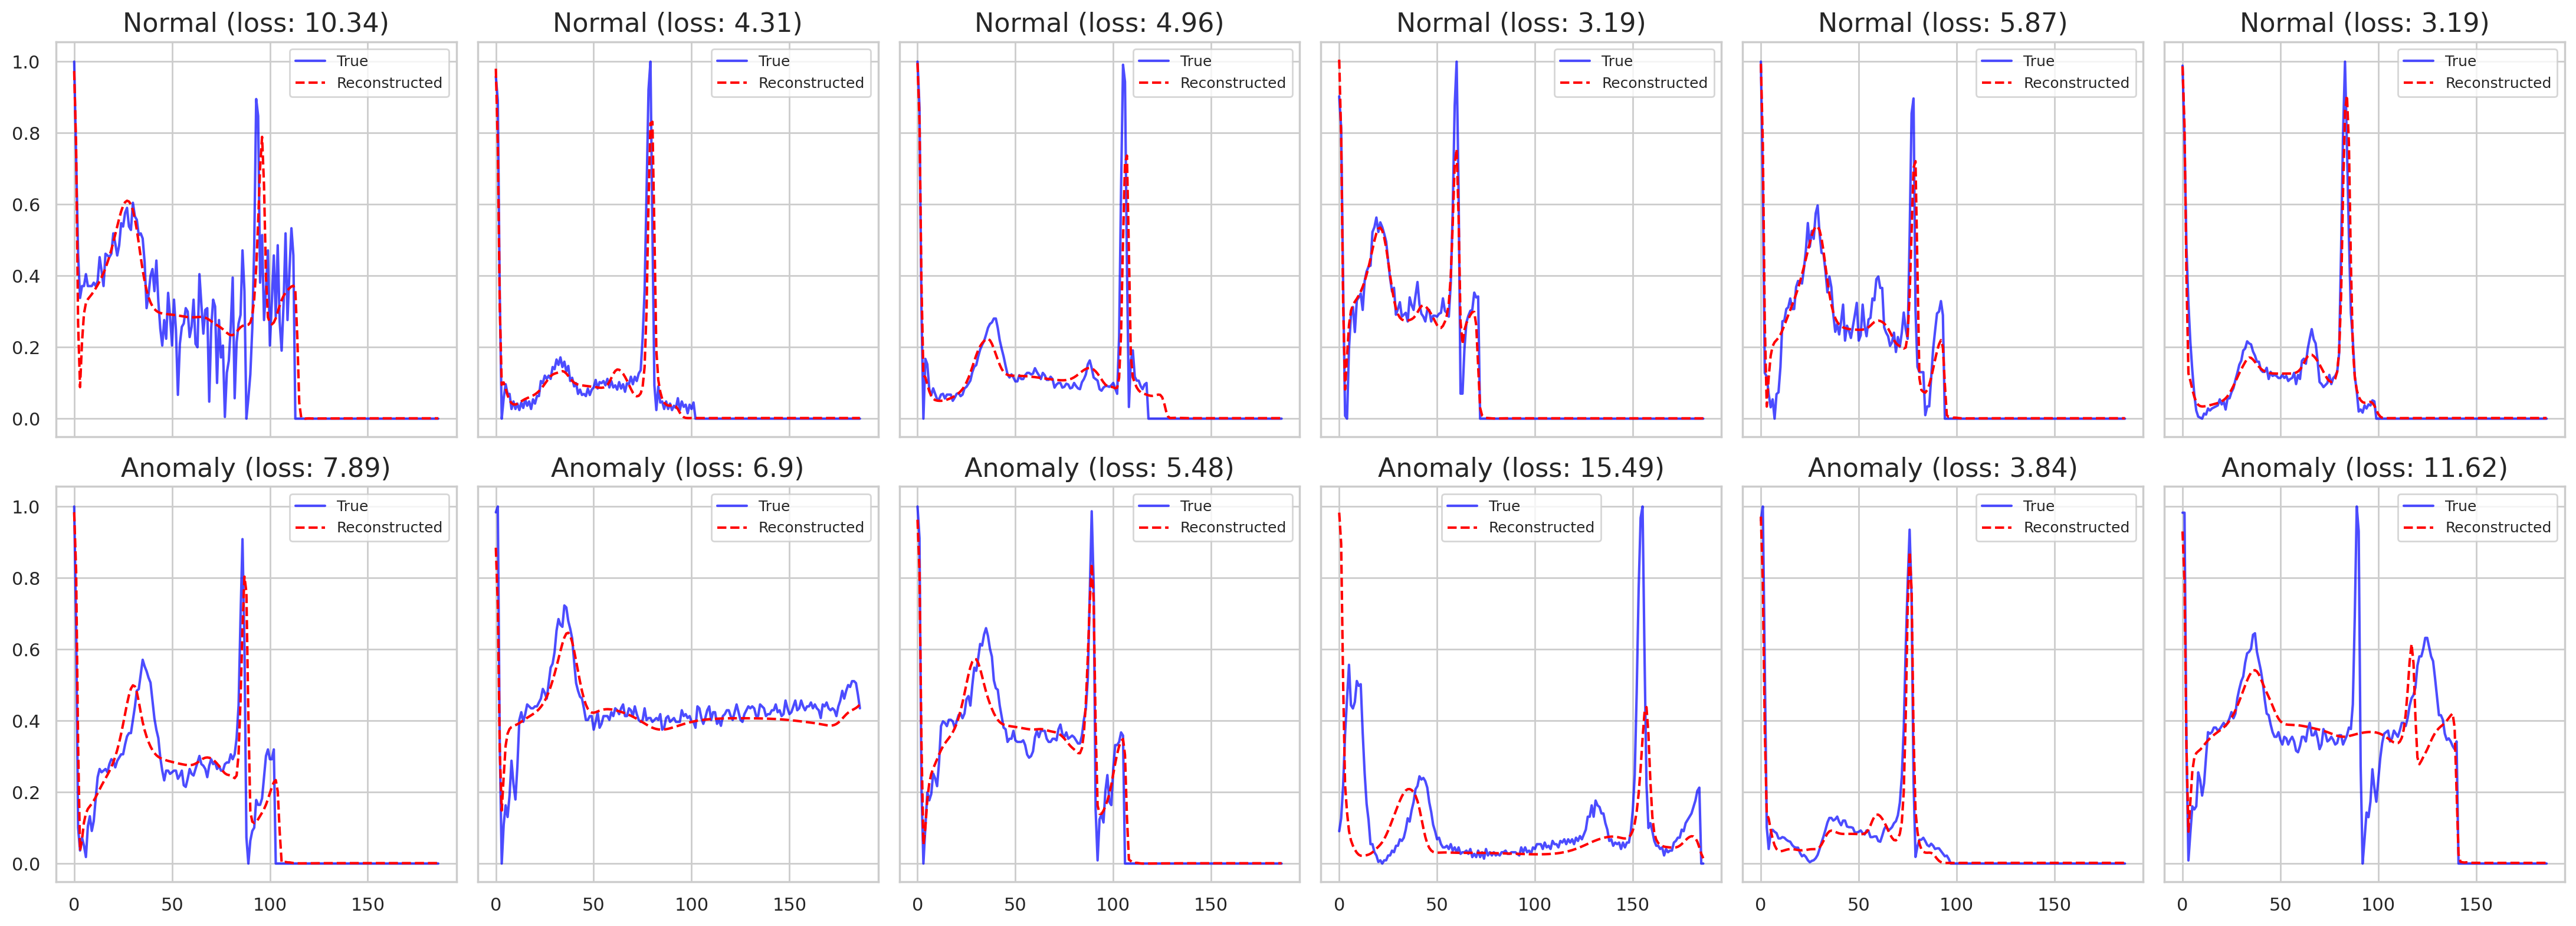

In [24]:
fig, axs = plt.subplots(
  nrows=2,
  ncols=6,
  sharey=True,
  sharex=True,
  figsize=(22, 8)
)


test_normal_loader_one_element = DataLoader(
    test_normal_dataset[:6],
    batch_size=1,
    shuffle=False
)

test_anomaly_loader_one_element = DataLoader(
    test_anomaly_dataset[:6],
    batch_size=1,
    shuffle=False
)


for i, data in enumerate(test_normal_loader_one_element):
  plot_prediction(data, model, title='Normal', ax=axs[0, i])

for i, data in enumerate(test_anomaly_loader_one_element):
  plot_prediction(data, model, title='Anomaly', ax=axs[1, i])

fig.tight_layout();

## Ссылки, приведенные в исходном блокноте

- [Sequitur - Recurrent Autoencoder (RAE)](https://github.com/shobrook/sequitur)
- [Towards Never-Ending Learning from Time Series Streams](https://www.cs.ucr.edu/~eamonn/neverending.pdf)